In [ ]:
import seaborn as sns
import pandas as pd 
from utils.score import get_summary  
from utils.df import * 
from utils.quadrants import *
import matplotlib.pyplot as plt # same group of quesitons to compare with humans but with gt condition to get the MG  

import sys 
sys.path.append('..')
from score_humans import get_vqa_mapper, VQAAnswerMapper 
import json

sns.set_theme(
    style="whitegrid",
    context="paper",
) 
with open('/home/work/yuna/HPA/evaluation/scored/humans/human_vqa_per_question.json', 'r') as f:
    data = json.load(f)
    
if isinstance(data, list) and len(data) > 0 and isinstance(data[0], list):
    records = [item for sublist in data for item in sublist]
    human_vqa = pd.DataFrame(records)
else:
    human_vqa = pd.DataFrame(data)

vqa_answers = get_vqa_mapper()  
vqamapper = VQAAnswerMapper()
vqamapper._load()
vqa_annot = vqamapper.annotations 


In [ ]:
human_vqa['model'] = "Humans" 
human_vqa['meta_model'] = "humans" 
human_vqa['condition'] = "inst blind" 
human_vqa.rename(columns={"mean_accuracy": 'correct', 'qid': 'question_id'}, inplace=True) 
human_vqa['correct'] = pd.to_numeric((human_vqa['correct'] * 100).round(1) , errors='coerce')
human_vqa['answer_similarity'] = pd.to_numeric((human_vqa['answer_similarity'] * 100).round(1) , errors='coerce')
human_vqa['question_type'] = human_vqa['question_id'].map(lambda qid: vqa_annot[int(qid)]['question_type'] if int(qid) in vqa_annot else None)
human_vqa['answer_type'] = human_vqa['question_id'].map(lambda qid: vqa_annot[int(qid)]['answer_type'] if int(qid) in vqa_annot else None)
human_vqa = human_vqa.drop_duplicates(subset=['participant_id', 'question_id'])
human_vqa = human_vqa[human_vqa['participant_id'] != '13f54aa2_20251204_125847']
qids = human_vqa.question_id.unique().astype(int)
human_vqa.head()

In [ ]:
model_results = {}
vqa_1k = get_summary('vqa_1k').drop_duplicates(subset=['condition', 'question_id', 'model'])
vqa_5k = get_summary('vqa_5k').drop_duplicates(subset=['condition', 'question_id', 'model']) 
vqa_5k['model'] = vqa_5k['model'].map(model_name_map)  
vqa_1k['model'] = vqa_1k['model'].map(model_name_map)  

model_vqa = vqa_1k[(vqa_1k['question_id'].isin(qids)) & (vqa_1k['condition'] == 'inst blind')].replace(model_name_map)
print(vqa_1k.condition.unique(),'condition mapped to-> ', model_vqa.condition.unique()) 
pmd = model_vqa[model_vqa['model'].isin(model_name_map.values())]  # pretrained models df on vqa blind data   
### combine human and model !
hm = pd.concat([model_vqa, human_vqa]) # just the blind conditions 
ag = hm.pivot_table(  
    index=['model'], 
    values=['correct', 'answer_similarity'], 
    columns=['answer_type'], 
    aggfunc=['mean'] ,
    margins=True,
    margins_name='Average'
)

# agg.to_latex('./tables/VQA_human-model_similarity-answer_type.tex', float_format="%.1f")  
ag.to_latex('./tables/1_VQA_human-pretrained-model_similarity-answer_type.tex', float_format="%.1f")   

pt = vqa_1k.pivot_table( 
    index=['model', 'question_id', 'answer_type', 'question_type'],  
    columns=['condition'],  
    values=['correct', 'answer_similarity'], 
    aggfunc=['mean'] # , 'count' 
) 

pt['MG'] = (
    pt[('mean', 'correct', '')]
    - pt[('mean', 'correct', 'inst blind')]
)
pt['inst_acc'] = pt[('mean', 'correct', 'inst blind')] - pt[('mean', 'correct', 'blind')] 
# pt.to_csv(f'./tables/mmstar_model_MG_by_qid.csv') 

pt = pt.dropna(subset=[
    ('mean','correct','inst blind'),
    ('mean','correct','blind')
])
pt.columns = [
    '_'.join([str(i) for i in col if str(i) != '']).strip('_')
    for col in pt.columns.values
]
pt = pt.reset_index()

   Loading VQA annotations from /home/work/yuna/VLMEval/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
85
89
['' 'blind' 'inst blind'] condition mapped to->  ['inst blind']


(array(['', 'blind', 'inst blind', 'sys inst blind'], dtype=object),
 Index(['question_type', 'answer_type', 'question_id', 'correct',
        'mean_answer_similarity', 'mean_answer_similarity_blind',
        'mean_answer_similarity_inst blind', 'mean_correct',
        'mean_correct_blind', 'mean_correct_inst blind', 'MG', 'inst_acc'],
       dtype='object'))

In [28]:
human_avg_by_qid = human_vqa.groupby(['question_type', 'answer_type', 'question_id'])['correct'].mean().reset_index()
human_avg_by_qid['question_id'] = human_avg_by_qid['question_id'].astype('int')
mms=pt.groupby(['question_id', 'question_type', 'answer_type']).mean(numeric_only=True).reset_index()
mms = mms[mms['question_id'].isin(qids)]
mms = pd.merge(human_avg_by_qid, mms, on =['question_type', 'answer_type', 'question_id'], how='inner', suffixes=('_human', '_model')) 
mms.columns 

Index(['question_type', 'answer_type', 'question_id', 'correct',
       'mean_answer_similarity', 'mean_answer_similarity_blind',
       'mean_answer_similarity_inst blind', 'mean_correct',
       'mean_correct_blind', 'mean_correct_inst blind', 'MG', 'inst_acc'],
      dtype='object')

In [ ]:
### filtered datafrmes 
df = hm[['meta_model', 'question_id', 'answer_type', 'question_type', 'model', 'question', 'answer', 'output', 'correct', 'answer_similarity']]
human_df = df[df['model'] == 'Humans'] # .dropna(axis=1)   
humanavg= human_df.groupby(['question_id', 'answer_type', 'question_type']).mean(numeric_only=True).reset_index() 
mhavg = pd.merge( df[df['model'] != 'Humans'] , humanavg, on=['question_id', 'answer_type', 'question_type'], how='left', suffixes=('_model', '_human') )# .dropna(axis=1)
# mhavg.groupby(['model']).count().head() # it has to be all 374 questions for each model 
# len(qids), # model_vqa.groupby(['model', 'question_id']).count()    

### human and model 
human_cols = human_vqa.participant_id.unique()
model_cols = pmd.model.unique() 

len(human_cols), len(model_cols), human_vqa.groupby('participant_id')['question_id'].nunique()   

(20,
 10,
 participant_id
 02f952bb_20251210_230336            374
 0756a860_20251124_133827            374
 14d2420f_20251208_150302            374
 218b2db5_20251126_084136            374
 29127478_20251202_100107            374
 2e184452_20251205_141511_cleaned    374
 3238ebaf_20251126_140604            374
 3a36e078_20251205_225238            374
 5d843d39_20251127_141921            374
 60de6bd6_20251210_170035            374
 6b3a1a8d_20251125_135446            374
 73df43f3_20251204_210431            374
 74d408e5_20251213_134035            374
 825ff3e9_20251210_192335            374
 9c5d09f3_20251209_121033            374
 a5909497_20251211_232822            374
 b9b2cb98_20251127_193952            374
 d1548553_20251125_202324            370
 dd0f9986_20251128_222537            374
 f616d5c7_20251203_212223            374
 Name: question_id, dtype: int64)

In [20]:
mms

,question_type,answer_type,question_id,correct,mean_answer_similarity,mean_answer_similarity_blind,mean_answer_similarity_inst blind,mean_correct,mean_correct_blind,mean_correct_inst blind,MG,inst_acc
0,are,yes/no,244750002,1000000.0,97.34,84.04,81.38,100.00,100.00,100.00,0.00,0.00
1,are,yes/no,325568007,883450.0,100.00,94.68,85.88,100.00,93.34,86.68,13.32,-6.66
2,are,yes/no,345361001,400000.0,100.00,73.40,73.40,100.00,0.00,0.00,100.00,0.00
3,are,yes/no,390760002,433100.0,84.04,84.04,78.72,59.98,59.98,46.64,13.34,-13.34
4,are,yes/no,447549001,550000.0,89.36,89.36,85.75,60.00,60.00,60.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
369,why,other,241340000,0.0,77.32,72.37,75.87,50.00,30.00,30.00,20.00,0.00
370,why,other,322482003,0.0,44.14,43.15,42.08,19.99,0.00,0.00,19.99,0.00
371,why,other,57508001,0.0,26.33,19.75,18.52,0.00,3.33,0.00,0.00,-3.33
372,why,other,80306002,0.0,100.00,38.61,36.34,100.00,0.00,0.00,100.00,0.00


In [29]:
mms["human_correct"] = (human_avg_by_qid["correct"] >= 50).astype(int)  
mms["model_correct"] = (mms["mean_correct_inst blind"] >= 50).astype(int) 
mms["cc_quadrant"] = mms.apply(cc_quadrant, axis=1) 
mms.to_csv('./vqa_quadrants.csv') 
mms.groupby("cc_quadrant")["MG"].mean()

cc_quadrant
Human-Only        71.304348
Model-Only        15.833333
Shared Correct     8.978468
Shared Wrong      63.872275
Name: MG, dtype: float64

In [36]:
mms.to_csv("./vqa_quadrants.csv")

In [38]:
mms

,question_type,answer_type,question_id,correct,mean_answer_similarity,mean_answer_similarity_blind,mean_answer_similarity_inst blind,mean_correct,mean_correct_blind,mean_correct_inst blind,MG,inst_acc,human_correct,model_correct,cc_quadrant
0,are,yes/no,244750002,100.000,97.34,84.04,81.38,100.00,100.00,100.00,0.00,0.00,1,1,Shared Correct
1,are,yes/no,325568007,88.345,100.00,94.68,85.88,100.00,93.34,86.68,13.32,-6.66,1,1,Shared Correct
2,are,yes/no,345361001,40.000,100.00,73.40,73.40,100.00,0.00,0.00,100.00,0.00,0,0,Shared Wrong
3,are,yes/no,390760002,43.310,84.04,84.04,78.72,59.98,59.98,46.64,13.34,-13.34,0,0,Shared Wrong
4,are,yes/no,447549001,55.000,89.36,89.36,85.75,60.00,60.00,60.00,0.00,0.00,1,1,Shared Correct
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,why,other,241340000,0.000,77.32,72.37,75.87,50.00,30.00,30.00,20.00,0.00,0,0,Shared Wrong
370,why,other,322482003,0.000,44.14,43.15,42.08,19.99,0.00,0.00,19.99,0.00,0,0,Shared Wrong
371,why,other,57508001,0.000,26.33,19.75,18.52,0.00,3.33,0.00,0.00,-3.33,0,0,Shared Wrong
372,why,other,80306002,0.000,100.00,38.61,36.34,100.00,0.00,0.00,100.00,0.00,0,0,Shared Wrong


In [ ]:
from utils.quadrants import model_name_map

df["new_question_type"] = df["question_type"].apply(map_question_type) 

In [ ]:
grouped = (
    df[df.dataset == "VQAv2"]
    .groupby(["question_type", "cc_quadrant"])
)

In [ ]:
qs = ["Human Wrong / Model Correct","Both Wrong", 'Both Correct', 'Human Correct / Model Wrong'] 
examples= []
for qud in qs: 
    examples.append(get_examples(qud) )
pd.concat(examples).to_csv('./tables/4-quadrant-ex.csv') 

TypeError: get_examples() missing 2 required positional arguments: 'df' and 'mms'

In [34]:
# from utils.quadrants import quadrant_proportions_table, median_mg_table  
quad_stat = pd.merge(median_mg_table(mms, "MG"), quadrant_proportions_table(mms), on =['cc_quadrant'], suffixes=('_MG_Acc', ''))
quad_stat.to_latex('./tables/4_VQA_quad_stat.tex', float_format="%.1f")   
quad_stat 

,cc_quadrant,mean,median,n,count,fraction
0,Human-Only,71.304348,70.000,23,23,0.061497
1,Model-Only,15.833333,19.995,60,60,0.160428
2,Shared Correct,8.978468,0.000,124,124,0.331551
3,Shared Wrong,63.872275,70.000,167,167,0.446524


/home/work/yuna/HPA/evaluation/analysis/utils/corr.py:138: RuntimeWarning: Mean of empty slice.
  mean_r = np.tanh(z.mean())
/home/work/.anaconda/envs/privacyovod_new_copy/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


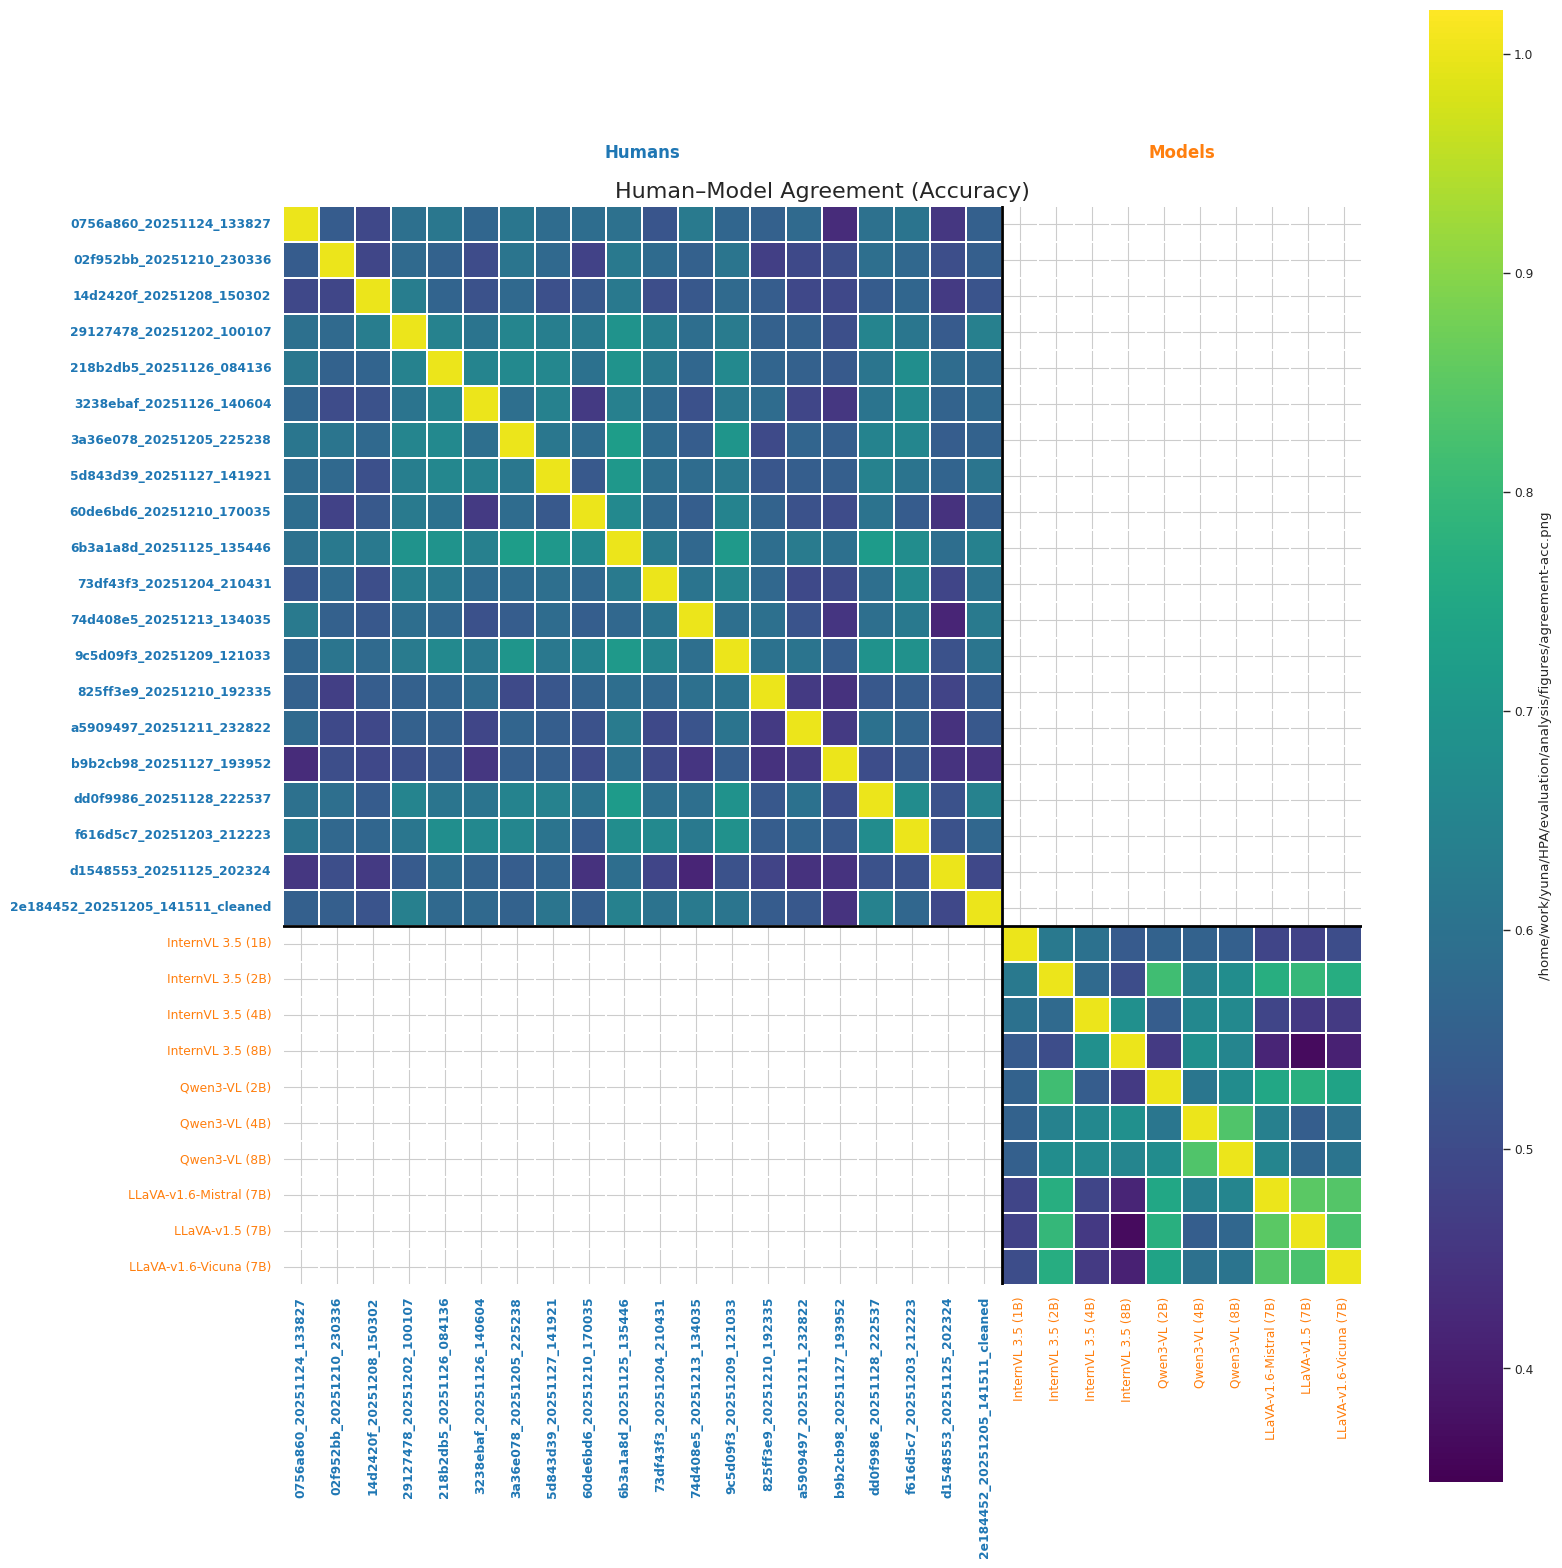

ValueError: Index contains duplicate entries, cannot reshape

In [9]:
from utils.corr import get_all_cm, get_agreements, transform_corr_table, plot_unified_agreement_heatmap
from utils.df import result_to_df 

res_HH, res_MM, res_HM  = get_agreements(human_vqa, pmd, n_boot=0)  # accuarcy 
corr_mat = get_all_cm(res_HH, res_MM, res_HM )
acc_corr = res_HM['corr_mat'].mean().sort_values().reset_index(name='acc_corr') 
plot_unified_agreement_heatmap(corr_mat, human_cols, model_cols , 'Human–Model Agreement (Accuracy)', '/home/work/yuna/HPA/evaluation/analysis/figures/agreement-acc.png') 
acc = pd.concat([result_to_df(res_HH), result_to_df(res_MM), result_to_df(res_HM)]) 

res_HH, res_MM, res_HM  =  get_agreements(human_vqa, pmd, 'answer_similarity', n_boot=0) 
corr_mat = get_all_cm(res_HH, res_MM, res_HM ) 
sim_corr = res_HM['corr_mat'].mean().sort_values().reset_index(name='sim_corr') 
acc = pd.concat([acc, result_to_df(res_HH), result_to_df(res_MM), result_to_df(res_HM)])
plot_unified_agreement_heatmap(corr_mat, human_cols, model_cols , 'Human–Model Agreement (Emb Similarity)', '/home/work/yuna/HPA/evaluation/analysis/figures/agreement-sim.png') 
transform_corr_table(acc).to_latex('./tables/3_spearman-interrater-vqa.tex', float_format="%.3f")   

### Does alignment with human hallucination structure under blind conditions predict grounded performance?

Pearson $r$ = -0.164 ($R^2$ = 0.027) | Spearman $\rho$ = -0.030


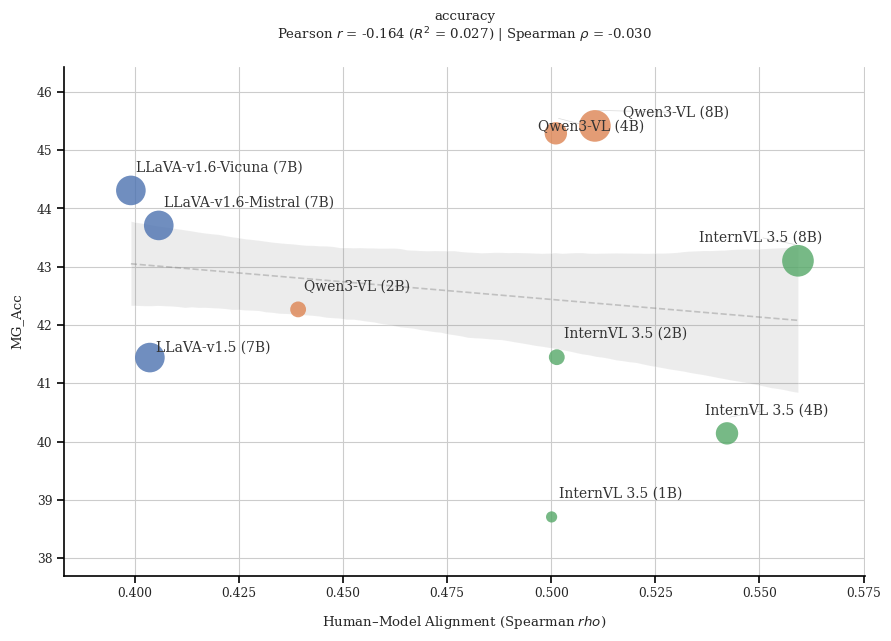

Pearson $r$ = -0.673 ($R^2$ = 0.453) | Spearman $\rho$ = -0.527


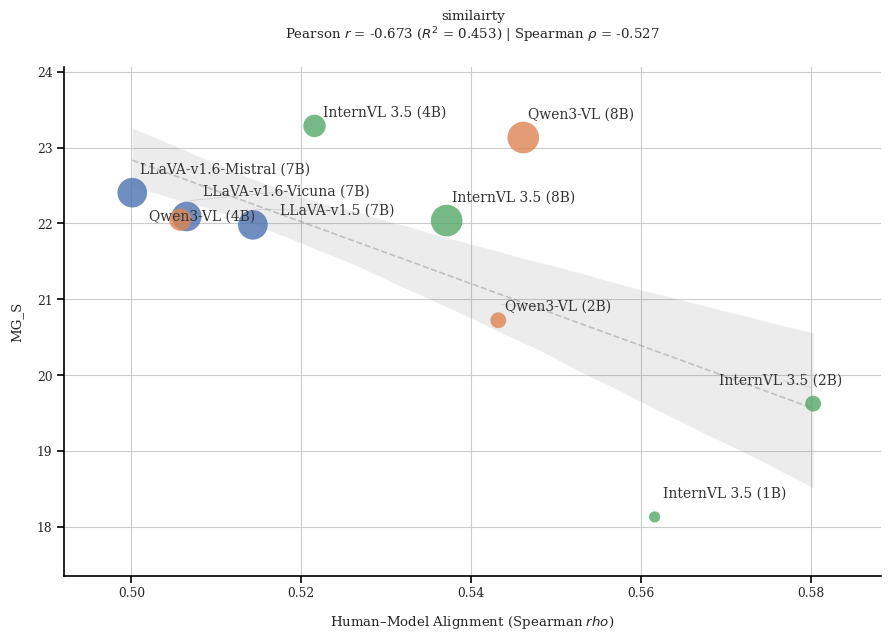

In [ ]:
from utils.plots import scatterplot, get_family, parse_size  
# from utils.df import aggregate_vqa, model_name_map, calculate_mg  

pcorr = pd.merge(acc_corr, sim_corr, on =['model']) 
df = calculate_mg(vqa_5k, filename='vqa_5k').groupby(['model']).mean(numeric_only=True).reset_index()  
pcorr = pd.merge(pcorr, df, on=['model']) 
pcorr = pcorr[['model', 'acc_corr', 'sim_corr', 'MG_Acc', 'MG_S']]
pcorr['family'] = pcorr['model'].map(get_family)
pcorr['model_size'] = pcorr['model'].map(parse_size) 

scatterplot(pcorr, x_col='acc_corr', y_col='MG_Acc', title='accuracy') 
scatterplot(pcorr, x_col='sim_corr', y_col='MG_S', title='similairty') 

In [ ]:
hm_wconditions = pd.concat([vqa_1k[(vqa_1k['question_id'].isin(qids))], human_vqa])
df_subset = calculate_mg(hm_wconditions, filename='vqa_subset').groupby(['model']).mean(numeric_only=True).reset_index()   
df_subset.groupby(['model']).mean(numeric_only=True).to_csv('./tables/VQA_subset_pretrained.csv')
hm_wconditions["human_correct"] = (hm_wconditions["human_blind_acc_q"] >= 0.5).astype(int)
hm_wconditions["model_correct"] = (hm_wconditions["model_blind_acc_q"] >= 0.5).astype(int)
hm_wconditions.model.unique() 

In [ ]:
hm_melted = hm.melt(
    id_vars=[col for col in hm.columns if col not in ['correct', 'answer_similarity']],
    value_vars=['correct', 'answer_similarity'],
    var_name='score_type',
    value_name='value'
)
hm_melted.columns 

Index(['image_id', 'question_id', 'question_type', 'question', 'answers',
       'multiple_choice_answer', 'answer_type', 'pid', 'output', 'model',
       'condition', 'meta_model', '﻿question_num', 'answer', 'confidence',
       'time_spent_seconds', 'answer_timestamp', 'participant_id',
       'answer_original', 'answer_raw', 'answer_normalized', 'gt_answers',
       'visual_gt', 'score_type', 'value'],
      dtype='object')

In [ ]:
from utils.plots import get_correlation_by_model 

results = []
for model in mg.model.unique(): 
    results.append(get_correlation_by_model(mg, model)[0]) 
    results.append(get_correlation_by_model(mg, model, score_col='correct')[0]) 

grouped = pd.DataFrame(results)
# grouped.to_csv('./tables/vqa_model_human_correlation.csv')   

In [ ]:
grouped['model_clean'] = grouped['model'].map(model_name_map)  
grouped['family'] = grouped['model_clean'].str.extract(r'([^(]+)').iloc[:, 0].str.strip()
grouped['model_size'] = grouped['model_clean'].apply(extract_size) 
for score_col in grouped["eval_metric"].unique():
    subset = grouped[grouped["eval_metric"] == score_col].sort_values(by=['model_clean'])


In [ ]:
cols = ['correct_model', 'answer_similarity_model', 'correct_human', 'answer_similarity_human']
for col in cols:
    pm[col] = pd.to_numeric(pm[col], errors='coerce')

pm = pm.groupby(['question_id'])[cols].mean() 
len((pm['correct_human'])), len(pm['correct_model']), len(pm['answer_similarity_human']), len(pm['answer_similarity_model'] ) 

/tmp/ipykernel_1961015/923178.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pm[col] = pd.to_numeric(pm[col], errors='coerce')


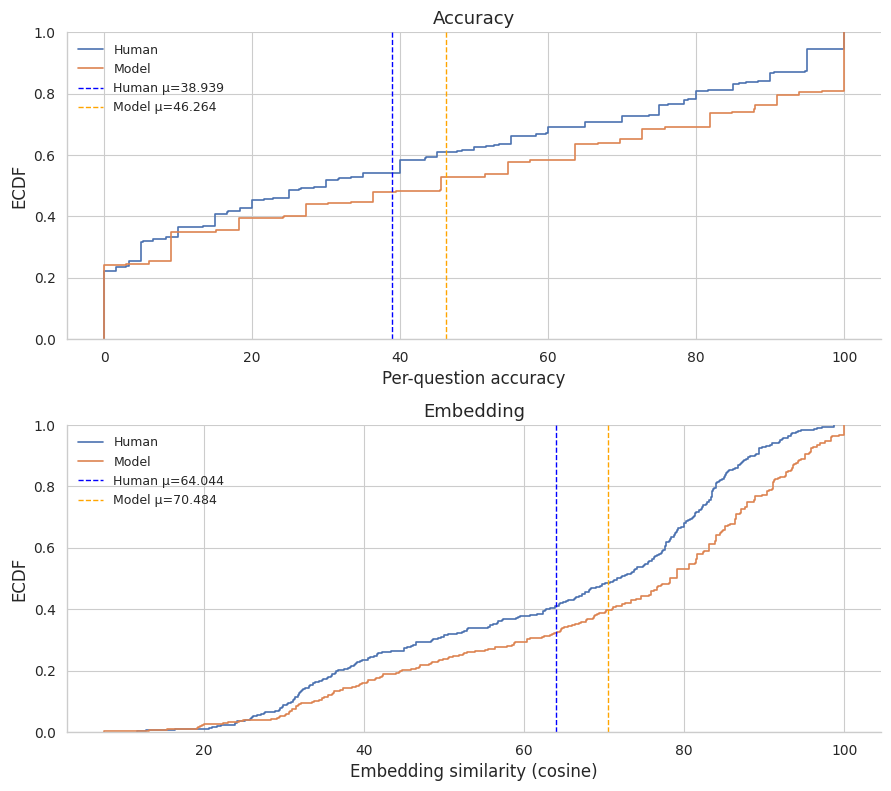

TypeError: cannot unpack non-iterable NoneType object

In [ ]:
alignments = [] 

alignments.append(acc_stat)
alignments.append(emb_stat)
pd.DataFrame(alignments)

In [ ]:
from utils.align import calculate_alignment_suite 

def aligned_histogram(human_acc, model_acc, human_emb, model_emb, modelname='Pretrained VLMs'):  

    x,y,x2,y2= human_acc, model_acc, human_emb, model_emb 
    
    acc_stat = calculate_alignment_suite(x, y) 
    acc_stat['metric'] = 'accuracy' 
    acc_stat['model'] = modelname 

    emb_stat = calculate_alignment_suite(x2, y2) 
    emb_stat['metric'] = 'answer_similarity'
    emb_stat['model'] = modelname 
    
    draw_histograms_vqa(x, y, x2, y2, acc_stat['Pearson_r'], acc_stat['KS_Stat'], emb_stat['Pearson_r'], emb_stat['KS_Stat'], modelname) 

    print(f"Accuracy\n$r={acc_stat['Pearson_r']:.2f}$, KS={acc_stat['KS_Stat']:.2f}")
    print(f"Embedding\n$r={emb_stat['Pearson_r']:.2f}$, KS={emb_stat['KS_Stat']:.2f}") 
    return acc_stat, emb_stat


Accuracy
$r=0.46$, KS=0.50
Embedding
$r=0.58$, KS=0.47


,Pearson_r,r_95_CI,Spearman_rho,Kappa_Quad,TVD,JS_Dist,KS_Stat,Wasserstein,Delta_Mean,metric,model
0,0.460,"[0.446, 0.474]",0.467,0.397,0.564,0.629,0.499,21.628,19.806,accuracy,Pretrained VLMs
1,0.582,"[0.57, 0.594]",0.492,0.489,0.609,0.637,0.471,12.942,12.538,answer_similarity,Pretrained VLMs


In [ ]:
for model in mg.model.unique():  
    df = mg[mg['model'] == model] 
    acc_stat, emb_stat = aligned_histogram(df['correct_human'], df['correct_model'], df['answer_similarity_human'], df['answer_similarity_model'], model) 

    alignments.append(acc_stat)
    alignments.append(emb_stat) 
    
pd.DataFrame(alignments)

Accuracy
$r=0.65$, KS=0.35
Embedding
$r=0.74$, KS=0.32
Accuracy
$r=0.63$, KS=0.37
Embedding
$r=0.76$, KS=0.35
Accuracy
$r=0.71$, KS=0.39
Embedding
$r=0.67$, KS=0.19
Accuracy
$r=0.73$, KS=0.37
Embedding
$r=0.70$, KS=0.29
Accuracy
$r=0.55$, KS=0.37
Embedding
$r=0.72$, KS=0.34
Accuracy
$r=0.64$, KS=0.39
Embedding
$r=0.67$, KS=0.36
Accuracy
$r=0.65$, KS=0.39
Embedding
$r=0.71$, KS=0.35
Accuracy
$r=0.50$, KS=0.38
Embedding
$r=0.66$, KS=0.37
Accuracy
$r=0.56$, KS=0.43
Embedding
$r=0.68$, KS=0.40
Accuracy
$r=0.73$, KS=0.42
Embedding
$r=0.74$, KS=0.39
Accuracy
$r=0.75$, KS=0.41
Embedding
$r=0.74$, KS=0.38
Accuracy
$r=0.73$, KS=0.39
Embedding
$r=0.73$, KS=0.31
Accuracy
$r=0.76$, KS=0.40
Embedding
$r=0.73$, KS=0.38
Accuracy
$r=0.52$, KS=0.45
Embedding
$r=0.65$, KS=0.42
Accuracy
$r=0.53$, KS=0.41
Embedding
$r=0.66$, KS=0.39
Accuracy
$r=0.76$, KS=0.38
Embedding
$r=0.73$, KS=0.34
Accuracy
$r=0.76$, KS=0.39
Embedding
$r=0.73$, KS=0.35
Accuracy
$r=0.66$, KS=0.39
Embedding
$r=0.73$, KS=0.36
Accuracy
$

,Pearson_r,r_95_CI,Spearman_rho,Kappa_Quad,TVD,JS_Dist,KS_Stat,Wasserstein,Delta_Mean,metric,model
0,0.597,"[0.577, 0.616]",0.602,0.561,0.564,0.612,0.378,14.404,7.326,accuracy,None
1,0.694,"[0.678, 0.71]",0.634,0.638,0.548,0.576,0.337,7.888,6.440,answer_similarity,None
2,0.650,"[0.587, 0.705]",0.651,0.613,0.564,0.609,0.353,13.553,4.911,accuracy,InternVL3_5-1B
3,0.736,"[0.685, 0.779]",0.681,0.680,0.572,0.606,0.321,7.806,5.847,answer_similarity,InternVL3_5-1B
4,0.629,"[0.563, 0.686]",0.651,0.590,0.567,0.614,0.374,14.693,6.337,accuracy,InternVL3_5-2B
...,...,...,...,...,...,...,...,...,...,...,...
67,0.578,"[0.506, 0.642]",0.472,0.477,0.602,0.633,0.455,13.535,13.471,answer_similarity,llava-v1.6-mistral-7b-hf_SFT_vqa_gt
68,0.501,"[0.42, 0.573]",0.513,0.476,0.564,0.609,0.348,13.508,4.733,accuracy,llava-1.5-7b-hf
69,0.686,"[0.628, 0.736]",0.621,0.629,0.610,0.652,0.350,7.518,4.570,answer_similarity,llava-1.5-7b-hf
70,0.499,"[0.418, 0.571]",0.510,0.461,0.564,0.616,0.401,15.666,10.170,accuracy,llava-v1.6-vicuna-7b-hf


In [55]:
results_df = pd.DataFrame(alignments)
rename_map = {
    "Spearman_rho": "Spearman_ρ (↑)",
    "Kappa_Quad": "Kappa_Quad (↑)",
    "TVD": "TVD (↓)",
    "JS_Dist": "JS_Dist (↓)",
    "KS_Stat": "KS_Stat (↓)",
    "Wasserstein": "Wasserstein (↓)",
    "Delta_Mean": "Δ_Mean (→0)",  # Bias is best when close to zero
    "metric": "Metric"
}

results_df = results_df.rename(columns=rename_map)
# Debug: Some columns may not be numeric, causing aggfunc='mean' to fail. Select only numeric columns.
numeric_cols = results_df.select_dtypes(include='number').columns
# Keep 'model' and 'Metric' for pivot
pivot_cols = ['model', 'Metric'] + list(numeric_cols.difference(['model', 'Metric']))
pivot_df = results_df[pivot_cols]
pivot_df = pivot_df.pivot_table(index='model', columns='Metric', aggfunc='mean')
pivot_df.to_csv('./tables/alignment.csv')
pivot_df

JS_Dist (↓)  \
Metric                                               accuracy   
model                                                           
InternVL3_5-1B                                          0.624   
InternVL3_5-2B                                          0.628   
InternVL3_5-4B                                          0.629   
InternVL3_5-8B                                          0.632   
InternVL3_5-8B_A1_vqa_gt                                0.655   
InternVL3_5-8B_A2_vqa_10_blind_inst                     0.652   
InternVL3_5-8B_A3_vqa_15_blind_inst                     0.650   
InternVL3_5-8B_A4_mmstar_15_blind_inst                  0.647   
InternVL3_5-8B_SFT_vqa_15_blind_inst                    0.650   
InternVL3_5-8B_SFT_vqa_gt                               0.659   
Pretrained VLMs                                         0.629   
Qwen3-4B                                                0.640   
Qwen3-VL-2B-Instruct                                    0.628   
Qwen3-VL-4B-Instruct                                    0.631   
Qwen3-VL-4B-Instruct_A1_vqa_gt                          0.653   
Qwen3-VL-4B-Instruct_A2_vqa_10_blind_inst               0.645   
Qwen3-VL-4B-Instruct_A3_vqa_15_blind_inst               0.647   
Qwen3-VL-4B-Instruct_A4_mmstar_15_blind_inst            0.646   
Qwen3-VL-4B-Instruct_SFT_vqa_15_blind_inst              0.645   
Qwen3-VL-4B-Instruct_SFT_vqa_gt                         0.657   
Qwen3-VL-8B-Instruct                                    0.633   
Qwen3-VL-8B-Instruct_A1_vqa_gt                          0.650   
Qwen3-VL-8B-Instruct_A2_vqa_10_blind_inst               0.647   
Qwen3-VL-8B-Instruct_A3_vqa_15_blind_inst               0.650   
Qwen3-VL-8B-Instruct_A4_mmstar_15_blind_inst            0.650   
Qwen3-VL-8B-Instruct_SFT_mmstar_15_blind_inst           0.650   
Qwen3-VL-8B-Instruct_SFT_vqa_15_blind_inst              0.648   
llava-1.5-7b-hf                                         0.626   
llava-v1.6-mistral-7b-hf                                0.631   
llava-v1.6-mistral-7b-hf_A1_vqa_gt                      0.662   
llava-v1.6-mistral-7b-hf_A2_vqa_10_blind_inst           0.644   
llava-v1.6-mistral-7b-hf_A3_vqa_15_blind_inst           0.646   
llava-v1.6-mistral-7b-hf_A4_mmstar_15_blind_inst        0.653   
llava-v1.6-mistral-7b-hf_SFT_mmstar_15_blind_inst       0.656   
llava-v1.6-mistral-7b-hf_SFT_vqa_15_blind_inst          0.638   
llava-v1.6-mistral-7b-hf_SFT_vqa_gt                     0.660   
llava-v1.6-vicuna-7b-hf                                 0.634   

                                                                     \
Metric                                            answer_similarity   
model                                                                 
InternVL3_5-1B                                                0.634   
InternVL3_5-2B                                                0.628   
InternVL3_5-4B                                                0.554   
InternVL3_5-8B                                                0.609   
InternVL3_5-8B_A1_vqa_gt                                      0.678   
InternVL3_5-8B_A2_vqa_10_blind_inst                           0.669   
InternVL3_5-8B_A3_vqa_15_blind_inst                           0.663   
InternVL3_5-8B_A4_mmstar_15_blind_inst                        0.633   
InternVL3_5-8B_SFT_vqa_15_blind_inst                          0.661   
InternVL3_5-8B_SFT_vqa_gt                                     0.685   
Pretrained VLMs                                               0.637   
Qwen3-4B                                                      0.817   
Qwen3-VL-2B-Instruct                                          0.639   
Qwen3-VL-4B-Instruct                                          0.663   
Qwen3-VL-4B-Instruct_A1_vqa_gt                                0.693   
Qwen3-VL-4B-Instruct_A2_vqa_10_blind_inst                     0.652   
Qwen3-VL-4B-Instruct_A3_vqa_15_blind_inst                     0.651   
Qwen3-VL-4B-Instruct_A4_mmsta